In [1]:
import torch

CFG = {
    "num_frames": 16,
    "input_size": 224,
    "batch_size": 20,
}
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
import torch
import torch.nn as nn
from torchvision.models.video import swin3d_s, Swin3D_S_Weights
from torch.autograd import Function

device = "cuda" if torch.cuda.is_available() else "cpu"

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)

class DeepfakeDetector(nn.Module):
    """
    EXACT training architecture (matches checkpoint keys):
    backbone: swin3d_s Kinetics-400 pretrained, head removed
    cls_head: LayerNorm(D) -> Linear(D,1)
    domain_head: LayerNorm(D) -> Linear(D,2) with GRL
    """
    def __init__(self, backbone, grl_lambda=0.0):
        super().__init__()
        self.backbone = backbone
        self.grl_lambda = grl_lambda

        # remove classification head
        self.backbone.head = nn.Identity()

        feat_dim = backbone.num_features  # authoritative for Swin3D in torchvision

        self.cls_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 1)
        )

        self.domain_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 2)
        )

    def forward(self, x):
        # expects (B,C,T,H,W)
        feats = self.backbone(x)  # (B,D)
        logits = self.cls_head(feats).squeeze(1)
        dom_logits = self.domain_head(grad_reverse(feats, self.grl_lambda))
        return logits, dom_logits

# Backbone: Video Swin 3D Small, Kinetics-400
weights = Swin3D_S_Weights.KINETICS400_V1
backbone = swin3d_s(weights=weights)

model = DeepfakeDetector(backbone, grl_lambda=0.0).to(device).eval()
print("Model rebuilt ✅", "feat_dim =", backbone.num_features, "| device =", device)

Model rebuilt ✅ feat_dim = 768 | device = cuda


In [3]:
ckpt_path = "/home/best_model.pth"
state = torch.load(ckpt_path, map_location=device)

missing, unexpected = model.load_state_dict(state, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

assert len(missing) == 0 and len(unexpected) == 0, "Checkpoint != model definition. Do NOT proceed."
print("Checkpoint loaded cleanly ✅")

Missing keys: []
Unexpected keys: []
Checkpoint loaded cleanly ✅


In [4]:
import os
import pandas as pd

ROOT = "/home/Celeb-DF-v2-testset"

def collect_videos(folder, label):
    paths = []
    folder = os.path.join(ROOT, folder)
    for vid in os.listdir(folder):
        if vid.endswith(".mp4"):
            paths.append((os.path.join(folder, vid), label))
    return paths

data = []
data += collect_videos("Celeb-real", 0)
data += collect_videos("YouTube-real", 0)
data += collect_videos("Celeb-synthesis", 1)

celeb_df = pd.DataFrame(data, columns=["path","class_label"])
celeb_df["domain"] = 2  # unused but kept for compatibility

print("Total CelebDF videos:", len(celeb_df))
celeb_df.head()

Total CelebDF videos: 518


,path,class_label,domain
0,/home/Celeb-DF-v2-testset/Celeb-real/id7_0006.mp4,0,2
1,/home/Celeb-DF-v2-testset/Celeb-real/id0_0001.mp4,0,2
2,/home/Celeb-DF-v2-testset/Celeb-real/id33_0005...,0,2
3,/home/Celeb-DF-v2-testset/Celeb-real/id10_0001...,0,2
4,/home/Celeb-DF-v2-testset/Celeb-real/id34_0006...,0,2


In [5]:
import cv2
import numpy as np
from torch.utils.data import Dataset

class CelebDataset(Dataset):
    def __init__(self, df, cfg):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg

    def sample_frames(self, path):
        cap = cv2.VideoCapture(path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        idxs = np.linspace(0, frame_count-1, self.cfg["num_frames"]).astype(int)
        frames = []

        for i in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                frame = np.zeros((224,224,3), dtype=np.uint8)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (self.cfg["input_size"], self.cfg["input_size"]))
            frame = frame / 255.0
            frames.append(frame)

        cap.release()
        frames = np.stack(frames)
        frames = frames.transpose(3, 0, 1, 2)
        return torch.tensor(frames, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video = self.sample_frames(row.path)
        label = torch.tensor(row.class_label).float()
        domain = torch.tensor(row.domain)
        return video, label, domain

In [6]:
from torch.utils.data import DataLoader

celeb_dataset = CelebDataset(celeb_df, CFG)

celeb_loader = DataLoader(
    celeb_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("CelebDF loader ready")

CelebDF loader ready


In [7]:
from sklearn.metrics import roc_auc_score
import numpy as np

@torch.no_grad()
def evaluate(loader):
    all_probs, all_labels = [], []

    for videos, labels, _ in loader:
        videos = videos.to(device)
        labels = labels.to(device)

        logits, _ = model(videos)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)

    auc = roc_auc_score(labels, probs)
    preds = (probs > 0.5).astype(int)
    acc = (preds == labels).mean()

    print(f"\n🎯 CelebDF-v2 CROSS-DATASET RESULTS")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")

    return probs, labels

celeb_probs, celeb_labels = evaluate(celeb_loader)


🎯 CelebDF-v2 CROSS-DATASET RESULTS
AUC: 0.5415
Accuracy: 0.6602


In [9]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

=== CelebDF-v2 Cross-Dataset Metrics (threshold=0.5) ===
ROC-AUC: 0.5415
PR-AUC (Average Precision): 0.6541
Accuracy : 0.6602
Precision: 0.6602
Recall   : 0.9941
F1-score : 0.7934

Confusion Matrix [[TN, FP],[FN, TP]]:
[[  4 174]
 [  2 338]] 

Classification Report:
              precision    recall  f1-score   support

         0.0     0.6667    0.0225    0.0435       178
         1.0     0.6602    0.9941    0.7934       340

    accuracy                         0.6602       518
   macro avg     0.6634    0.5083    0.4185       518
weighted avg     0.6624    0.6602    0.5357       518



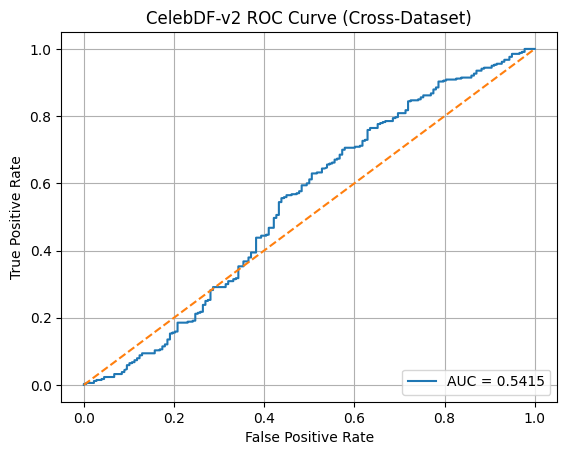

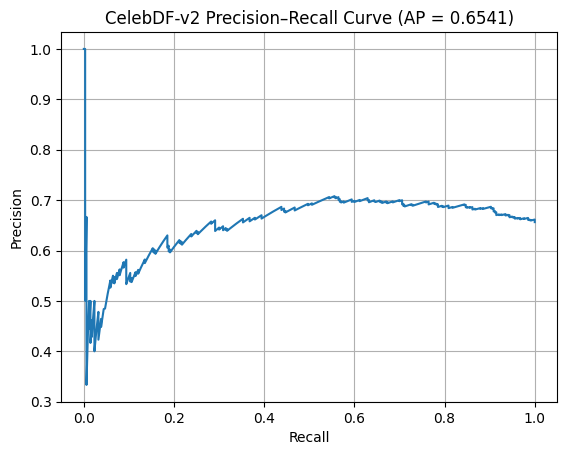

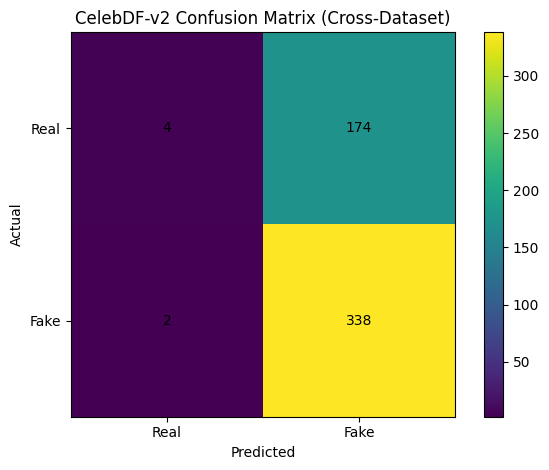

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

threshold = 0.5
preds = (celeb_probs >= threshold).astype(int)

acc = accuracy_score(celeb_labels, preds)
prec = precision_score(celeb_labels, preds, zero_division=0)
rec = recall_score(celeb_labels, preds, zero_division=0)
f1 = f1_score(celeb_labels, preds, zero_division=0)

cm = confusion_matrix(celeb_labels, preds)  # [[TN,FP],[FN,TP]]

# ROC
fpr, tpr, _ = roc_curve(celeb_labels, celeb_probs)
roc_auc = auc(fpr, tpr)

# PR
pr_precision, pr_recall, _ = precision_recall_curve(celeb_labels, celeb_probs)
ap = average_precision_score(celeb_labels, celeb_probs)

print("=== CelebDF-v2 Cross-Dataset Metrics (threshold=0.5) ===")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {ap:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix [[TN, FP],[FN, TP]]:")
print(cm, "\n")

print("Classification Report:")
print(classification_report(celeb_labels, preds, digits=4, zero_division=0))

# --- Plot ROC (Graph 1) ---
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CelebDF-v2 ROC Curve (Cross-Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# --- Plot PR (Graph 2) ---
plt.figure()
plt.plot(pr_recall, pr_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"CelebDF-v2 Precision–Recall Curve (AP = {ap:.4f})")
plt.grid(True)
plt.show()

# --- Confusion Matrix Image ---
plt.figure()
plt.imshow(cm)
plt.title("CelebDF-v2 Confusion Matrix (Cross-Dataset)")
plt.colorbar()
classes = ["Real", "Fake"]
plt.xticks(range(2), classes)
plt.yticks(range(2), classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()